# BERT MODEL

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments,Trainer, DataCollatorWithPadding

In [3]:
parquet_file_path = "../data/train-00000-of-00001.parquet"
df = pd.read_parquet(parquet_file_path)

text_column = "text"
label_column = "label"

num_labels = 6

# Check class distribution before balancing
print("Before balancing:")
print(df['label'].value_counts())

# Cap each class at 8000 samples (classes with fewer than 8000 keep all their rows)
df = df.groupby('label', group_keys=False).apply(
    lambda x: x.sample(n=min(len(x), 8000), random_state=42)
)

# Shuffle so rows aren't grouped by label
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nAfter balancing:")
print(df['label'].value_counts())

Before balancing:
label
1    141067
0    121187
3     57317
4     47712
2     34554
5     14972
Name: count, dtype: int64

After balancing:
label
4    8000
5    8000
0    8000
2    8000
1    8000
3    8000
Name: count, dtype: int64


C:\Users\aiman\AppData\Local\Temp\ipykernel_40520\2628735323.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('label', group_keys=False).apply(


In [4]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df[label_column]
)

raw_datasets = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df.reset_index(drop=True))
})

In [5]:
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
    return tokenizer(examples[text_column], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Map: 100%|██████████| 9600/9600 [00:00<00:00, 82631.46 examples/s]


In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, predictions)
    report = classification_report(labels, predictions, output_dict=True, zero_division=0)

    return {
        "accuracy": acc,
        "f1_macro": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"]
    }

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9785.60it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Make sure results directory is present in the current folder
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch", # Changed from evaluation_strategy to eval_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=50,
    fp16=False, # Set to True if training on a GPU that supports half-precision
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,)

In [ ]:
print("Starting training...")
trainer.train()

print("\nRunning final evaluation on validation set...")
eval_results = trainer.evaluate()
print(f"Validation Accuracy: {eval_results['eval_accuracy']:.4f}")

# Generate and print the complete text-based classification report
predictions_output = trainer.predict(tokenized_datasets["validation"])
preds = np.argmax(predictions_output.predictions, axis=-1)
true_labels = predictions_output.label_ids

Accuracy: 0.9491666666666667
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1600
           1       0.99      0.91      0.95      1600
           2       0.93      0.99      0.96      1600
           3       0.96      0.95      0.95      1600
           4       0.93      0.90      0.91      1600
           5       0.91      1.00      0.95      1600

    accuracy                           0.95      9600
   macro avg       0.95      0.95      0.95      9600
weighted avg       0.95      0.95      0.95      9600



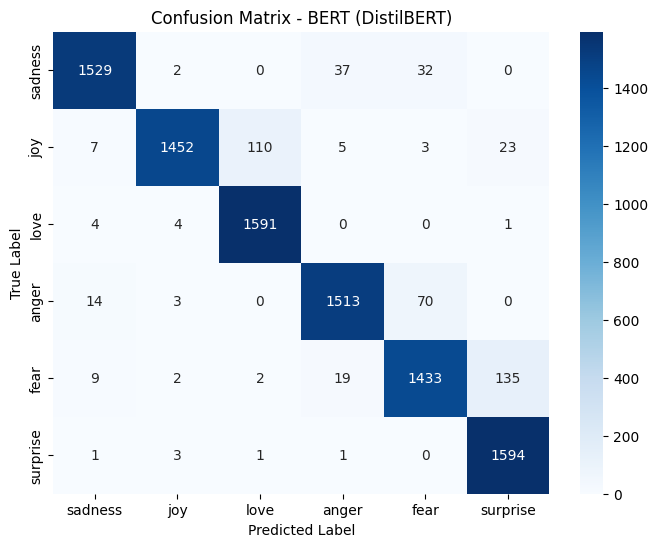

In [ ]:
print("Accuracy:", accuracy_score(true_labels, preds))
print(classification_report(true_labels, preds, zero_division=0))

# Create confusion matrix
cm = confusion_matrix(true_labels, preds)

# Emotion names (change according to your dataset mapping)
labels = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.title('Confusion Matrix - BERT (DistilBERT)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
import shutil

shutil.make_archive('saved_streamlit_model', 'zip', 'saved_streamlit_model')

'/content/saved_streamlit_model.zip'

In [9]:
output_model_dir = "./saved_streamlit_model"

model.save_pretrained(output_model_dir)
tokenizer.save_pretrained(output_model_dir)

print(f"\nModel and tokenizer successfully saved to '{output_model_dir}'!")
print("You can now load this folder directly into your Streamlit application.")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.68it/s]


Model and tokenizer successfully saved to './saved_streamlit_model'!
You can now load this folder directly into your Streamlit application.
